<a href="https://colab.research.google.com/github/wxseem-dev/AI-MRI-Alzheimer-s-Detection/blob/main/AI_MRI_Alzheimer's_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Load the Parquet Files

## Load the specified parquet file

### Subtask:
Convert from bytes to pixel brightness



**Reasoning**:
Update the file path in the existing code cell to load the specified parquet file and execute the cell.



## Inspect the dataframe

### Subtask:
Save to pandas df



**Reasoning**:
Display the column names, data types, and first few rows of the DataFrame to understand its structure and the nature of the image data.



## Extract and display images

### Subtask:
Based on the DataFrame structure, write code to extract the image data (e.g., if it's in a specific column) and display the images. This might require using libraries like Pillow or OpenCV.


**Reasoning**:
Import PIL and iterate through the first few rows of the dataframe to extract and display the images.



In [ ]:
# AI/ML randomness
import numpy as np
import torch

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print("Full seed (NumPy, PyTorch, CUDA) set to 42")

Full seed (NumPy, PyTorch, CUDA) set to 42


In [ ]:
# Ensure pyarrow is installed in this kernel
!pip install --quiet pyarrow
!pip install pandas Pillow kagglehub ipywidgets numpy matplotlib pyarrow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 70.7 MB/s eta 0:00:00


In [ ]:

import pandas as pd
from PIL import Image
import io
import numpy as np
import os
import pandas as pd
import pyarrow.parquet as pq
import pyarrow as pa
import matplotlib.pyplot as plt


In [ ]:
train_df = pd.read_parquet("dataset/train.parquet")
test_df  = pd.read_parquet("dataset/test.parquet")

In [ ]:
# Load parquet files
# Make sure to reference download instructions. You have to download the kaggle dataset and upload it, rename it to a data directory. Video guide coming soon
#from: https://drive.google.com/drive/folders/12-1XR8df-rYkwJuMqMgXYQ9dm6EoDx0f?usp=drive_link
#quickstart guide: https://www.youtube.com/watch?v=WPRarAeelAM
#Original source + description: https://advp.niagads.org/downloads

def bytes_to_pixels(b: bytes) -> np.ndarray:
    """
    Convert raw image bytes (e.g. JPEG/PNG) into a 2D numpy array of pixel values (grayscale).
    """

    """
    The image is converted to grayscale due to tissue density from dark to light, thats how MRI machines work.
    The parquet files store the actual raw bytes of the image in each row which has to transferred from bytes to an image that can be read
    If the picture is grayscale it is 1 number per pixel because we represent brightness instead of colour, so the model has to learn less and trains faster.
    This reduces complexity. 0 - black, 255 - white in a 2d array
    Converting to arrays lets the model work because neural networks process numbers not pictures.
    """
    img = Image.open(io.BytesIO(b))  # convert to grayscale
    return np.array(img)

    """
    Real world data is extremely messy, the creator the parquet file may have combined
    different datasets from sources, changed the format or used different serialisation methods.
    Therefore, we have to account for those edge cases.
    """
def extract_bytes(blob):
    """
    Unwrap a dict‐wrapped binary payload if needed,
    otherwise return blob directly.
    """
    if isinstance(blob, dict):
        # try common keys
        for key in ("bytes", "data", "image"):
            if key in blob and isinstance(blob[key], (bytes, bytearray)):
                return blob[key]
        # fallback: first bytes‐like value
        for v in blob.values():
            if isinstance(v, (bytes, bytearray)):
                return v
        raise TypeError(f"No bytes found in dict payload: {list(blob.keys())}")
    return blob

train_df["image"] = train_df["image"].apply(lambda blob: bytes_to_pixels(extract_bytes(blob)))
test_df["image"]  = test_df["image"].apply(lambda blob: bytes_to_pixels(extract_bytes(blob)))




In [ ]:
# Dataset overview

print("Number of rows in dataset: ", len(train_df))
print("Columns:")
print(train_df.columns)
print("Image count: ", train_df['image'].count())
print("Label count: ", train_df['label'].count())
print(train_df.info())
print("-------------------")

#print("Unique image values: ", train_df['image'].unique())
print("Unique label values: ", train_df['label'].unique())

print("largest class: ", train_df['label'].value_counts().idxmax())
print("largest class count: ", train_df['label'].max())

print("smallest class: ", train_df['label'].value_counts().idxmin())
print("smallest class count: ", train_df['label'].min())

counts = train_df['label'].value_counts()
ratio = counts.max() / counts.min()
print("Class imbalance ratio: ", ratio)

Number of rows in dataset:  5120
Columns:
Index(['image', 'label'], dtype='object')
Image count:  5120
Label count:  5120
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5120 entries, 0 to 5119
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   5120 non-null   object
 1   label   5120 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 80.1+ KB
None
-------------------
Unique label values:  [2 0 3 1]
largest class:  2
largest class count:  3
smallest class:  1
smallest class count:  0
Class imbalance ratio:  52.36734693877551


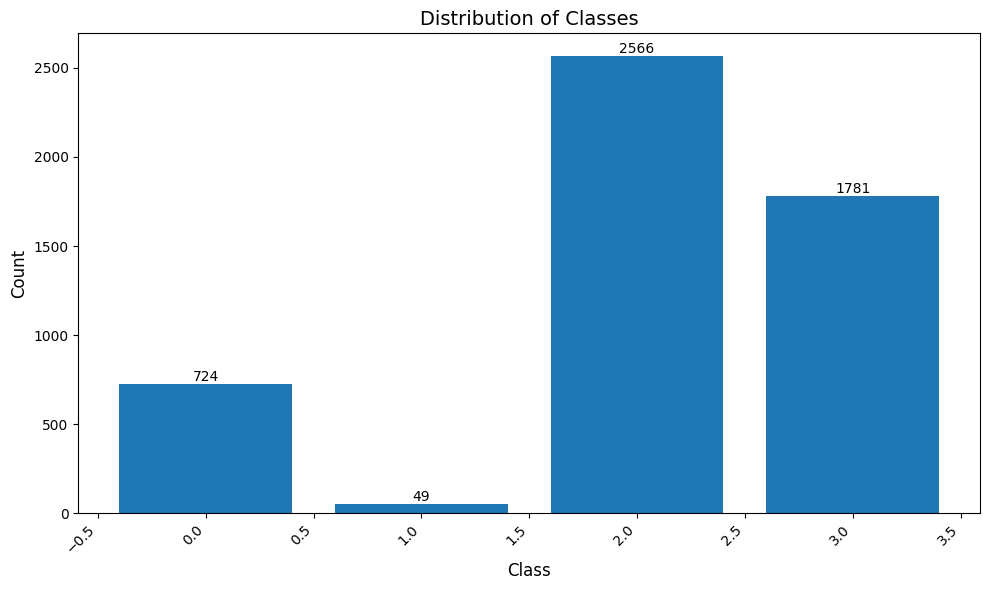

In [ ]:
# Data Visualisation

import matplotlib.pyplot as plt

counts = train_df['label'].value_counts()

# figure size
plt.figure(figsize=(10,6))

# draw bar char
bars = plt.bar(counts.index, counts.values, color='steelblue')

# title and axis labels
plt.title('Distribution of Classes', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)

# rotation of x-axis labels to avoid overlap
plt.xticks(rotation=45, ha='right')

# numeric labels
bars = plt.bar(counts.index, counts.values)
plt.bar_label(bars)

# show the plot
plt.tight_layout()
plt.show()


Train dataset:
1. label = 2


/tmp/ipykernel_6194/4133365528.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pixels.astype("uint8"), mode="L")


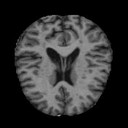

2. label = 0


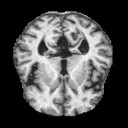

3. label = 3


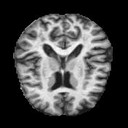

4. label = 3


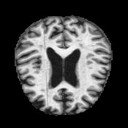

5. label = 2


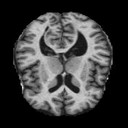

6. label = 2


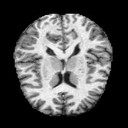

7. label = 2


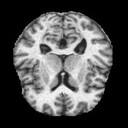

8. label = 2


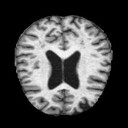

9. label = 3


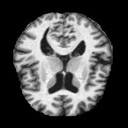

10. label = 2


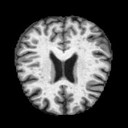

Test dataset:
1. label = 3


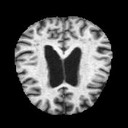

2. label = 0


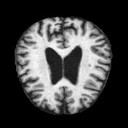

3. label = 2


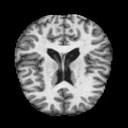

4. label = 3


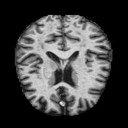

5. label = 0


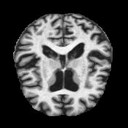

6. label = 3


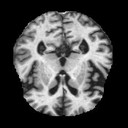

7. label = 2


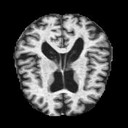

8. label = 2


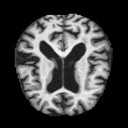

9. label = 2


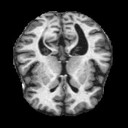

10. label = 3


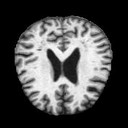

In [ ]:
def display_images(df, n=10):
    """
    Display the first n grayscale images (numpy arrays) from df
    along with their labels. Assumes df has columns 'image' and 'label'.
    """
    for i, (_, row) in enumerate(df.head(n).iterrows(), start=1):
        pixels = row["image"]
        label = row.get("label", "")
        # Create a PIL image in 'L' mode (8-bit pixels, black and white)
        img = Image.fromarray(pixels.astype("uint8"), mode="L")
        print(f"{i}. label = {label}")
        display(img)

print("Train dataset:")
display_images(train_df)
print("Test dataset:")
display_images(test_df)

class images: [array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8) ...
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0

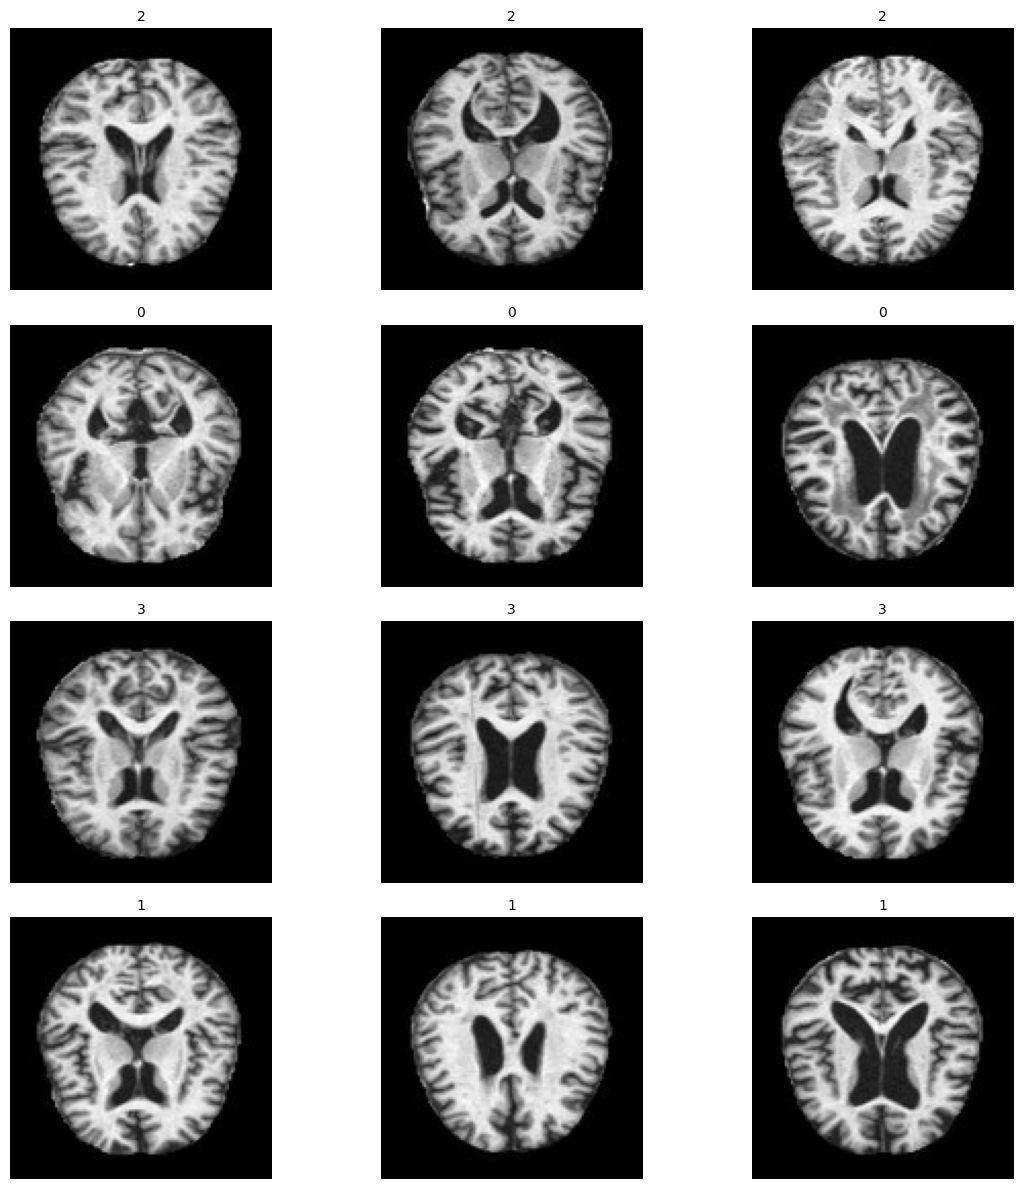

In [ ]:
# Image property analysis

def show_images_per_class(df, n_rows = 4, n_cols = 3, figsize=(12,12)):

  # display 4x3 grid of images

  classes = train_df['label'].unique()
  # if mre classes exist than rows, take first n_rows classes
  selected_classes = classes[:n_rows]

  fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
  # if only one row where axes is 1d, make it 2d for consistent indexing

  if n_rows == 1:
    axes = axes.reshape(1, -1)

  for row, cls in enumerate(selected_classes):
    # filter images for this class
    class_images = train_df[train_df['label'] == cls]['image'].values
    print("class images:", class_images)

    # take up to n_cols images
    for col in range(n_cols):
      ax = axes[row, col]
      if col < len(class_images):
        img = class_images[col] # already a numpy array
        ax.imshow(img, cmap='gray')
        ax.set_title(f"{cls}", fontsize=10)
      else:
        ax.axis('off')
      ax.axis('off')

  plt.tight_layout()
  plt.show()

show_images_per_class(train_df)


In [ ]:
# 5 random images
random_indices = np.random.choice(len(train_df), size=5, replace=False)

for idx in random_indices:
    img = train_df.iloc[idx]['image']
    print(f"----- Index {idx} (label = {train_df.iloc[idx]['label']}) -----")
    print(f"Shape: {img.shape}")
    print(f"Min pixel value: {img.min()}")
    print(f"Max pixel value: {img.max()}")
    print(f"Data type: {img.dtype}\n")


print("----------------------------------------------")

# consistency check
first_shape = train_df.iloc[0]['image'].shape
print(f"Reference shape (first image): {first_shape}")

for i in range(1, min(21, len(train_df))):
  current_shape = train_df.iloc[i]['image'].shape
  if current_shape != first_shape:
    print(f"WARNING: Image at index {i} has shape {current_shape} (different from {first_shape})")
  else:
    print(f"Index {i}: OK")

----- Index 530 (label = 0) -----
Shape: (128, 128)
Min pixel value: 0
Max pixel value: 255
Data type: uint8

----- Index 1729 (label = 3) -----
Shape: (128, 128)
Min pixel value: 0
Max pixel value: 246
Data type: uint8

----- Index 1010 (label = 2) -----
Shape: (128, 128)
Min pixel value: 0
Max pixel value: 255
Data type: uint8

----- Index 1149 (label = 3) -----
Shape: (128, 128)
Min pixel value: 0
Max pixel value: 254
Data type: uint8

----- Index 1383 (label = 3) -----
Shape: (128, 128)
Min pixel value: 0
Max pixel value: 251
Data type: uint8

----------------------------------------------
Reference shape (first image): (128, 128)
Index 1: OK
Index 2: OK
Index 3: OK
Index 4: OK
Index 5: OK
Index 6: OK
Index 7: OK
Index 8: OK
Index 9: OK
Index 10: OK
Index 11: OK
Index 12: OK
Index 13: OK
Index 14: OK
Index 15: OK
Index 16: OK
Index 17: OK
Index 18: OK
Index 19: OK
Index 20: OK


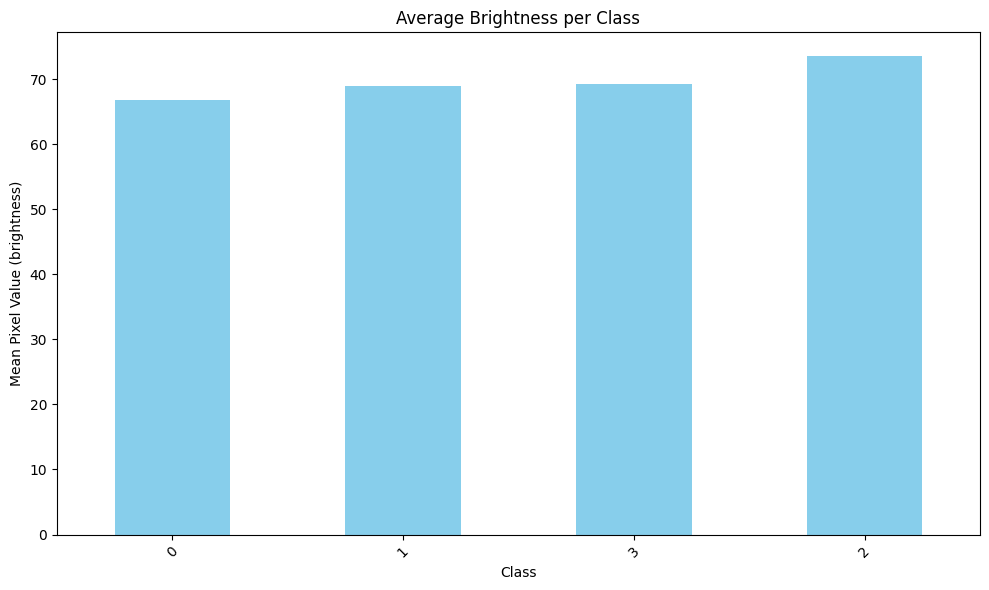

In [ ]:
# class-specific average brightness (bar char)

# calculate average brightness for each image
train_df['avg_brightness'] = train_df['image'].apply(lambda img: np.mean(img))

# group by label and comput mean rightness per class
class_brightness = train_df.groupby('label')['avg_brightness'].mean().sort_values()

# bar chart
plt.figure(figsize=(10, 6))
class_brightness.plot(kind='bar', color='skyblue')
plt.title('Average Brightness per Class')
plt.xlabel('Class')
plt.ylabel('Mean Pixel Value (brightness)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

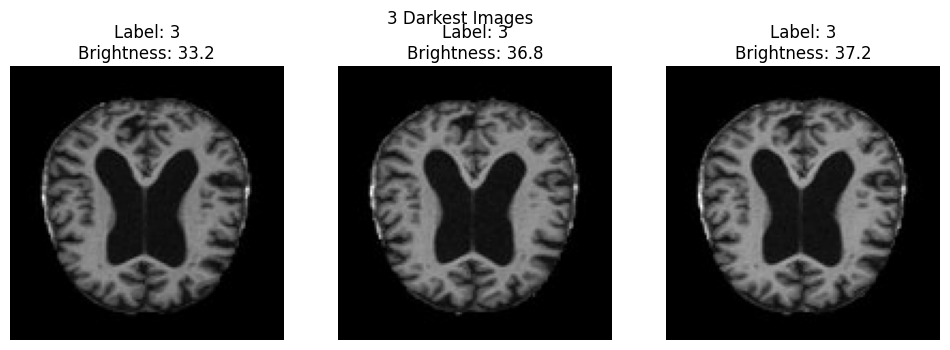

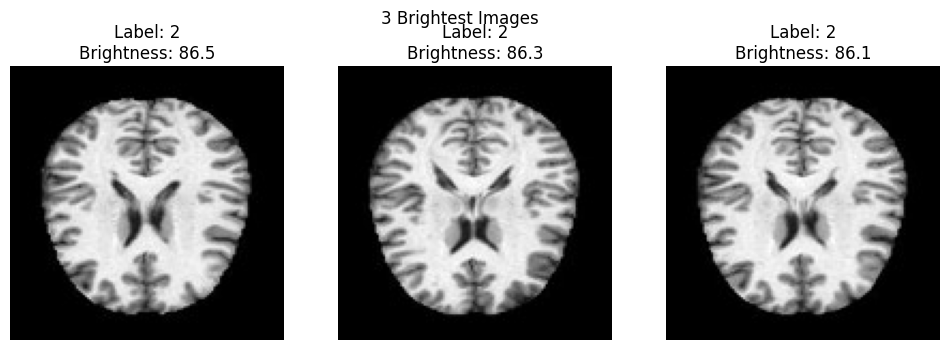

In [ ]:
# finding outliers in the data

# get darkest 3 (lowest brightness)
darkest = train_df.nsmallest(3, 'avg_brightness')
# get brightest 3 (highest brightness)
brightest = train_df.nlargest(3, 'avg_brightness')

# display the outliers
def show_images_with_labels(images_df, title):
    fig, axes = plt.subplots(1, len(images_df), figsize=(12, 4))
    if len(images_df) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, images_df.iterrows()):
        ax.imshow(row['image'], cmap='gray')
        ax.set_title(f"Label: {row['label']}\nBrightness: {row['avg_brightness']:.1f}")
        ax.axis('off')
    plt.suptitle(title)
    plt.show()

show_images_with_labels(darkest, "3 Darkest Images")
show_images_with_labels(brightest, "3 Brightest Images")

In [ ]:
# ------- CNN & AI/ML MODEL FINETUNING --------- #

In [ ]:
!pip install torch torchvision matplotlib seaborn pandas numpy scikit-learn

In [ ]:
# imports and GPU check
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# defining custom MRI dataset

class MRIDataset(Dataset):
  def __init__(self, dataframe, transform=None):
     self.dataframe = dataframe.reset_index(drop=True)
     self.transform = transform
  def __len__(self):
    return len(self.dataframe)
  def __getitem__(self, idx):
    img = self.dataframe.iloc[idx]['image']
    label = self.dataframe.iloc[idx]['label']
    img = torch.from_numpy(img).float().unsqueeze(0) / 255.0
    if self.transform:
      img = self.transform(img)
    return img, label

In [ ]:
# splitting train_df into 80% training and 20% validation and creating dataloaders
train_sub_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['label'])
print(f"Training samples: {len(train_sub_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

batch_size = 32
train_dataset = MRIDataset(train_sub_df)
val_dataset = MRIDataset(val_df)
test_dataset = MRIDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Quick check
images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape}")
print(f"Batch label shape: {labels.shape}")

Training samples: 4096
Validation samples: 1024
Test samples: 1280
Batch image shape: torch.Size([32, 1, 128, 128])
Batch label shape: torch.Size([32])


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights based on training set labels
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_sub_df['label']),
    y=train_sub_df['label']
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class weights: {class_weights}")  # e.g., [0.8, 9.0, 0.3, 0.5] - Class 1 will be highest

Class weights: tensor([ 1.7686, 26.2564,  0.4988,  0.7186], device='cuda:0')


In [ ]:
# our tiny cnn model

class TinyCNN(nn.Module):
  def __init__(self, num_classes=4):
    super(TinyCNN, self).__init__()

    self.features = nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, padding=1), # extracts patterns (edges, textures) from the image
        nn.ReLU(), # introduces non-linearity (helps learn complex patterns)
        nn.MaxPool2d(2, 2), # reduces size (makes the model faster and more robust)
        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),
    )
    self.classifier = nn.Sequential(
        nn.Flatten(), # turns 2d features into a flat vector
        nn.Linear(64 * 16 * 16, 128), # fully connected layers for final classificication
        nn.ReLU(),
        nn.Dropout(0.5), # prevents overfitting by randomly turning off osme neurons during training
        nn.Linear(128, num_classes),
    )
  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

model = TinyCNN(num_classes=4).to(device)
print(model)

TinyCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [ ]:
# defining training and evaluation functions

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [ ]:
# setting hyperparameters and run training for a few epochs

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 5

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}\n")

Epoch 1/5
Train Loss: 1.3830 Acc: 0.3345
Val Loss: 1.3683 Acc: 0.5010

Epoch 2/5
Train Loss: 1.3667 Acc: 0.3577
Val Loss: 1.4100 Acc: 0.3477

Epoch 3/5
Train Loss: 1.3758 Acc: 0.3850
Val Loss: 1.3540 Acc: 0.3389

Epoch 4/5
Train Loss: 1.3595 Acc: 0.3718
Val Loss: 1.3496 Acc: 0.2012

Epoch 5/5
Train Loss: 1.3606 Acc: 0.4004
Val Loss: 1.3153 Acc: 0.4893



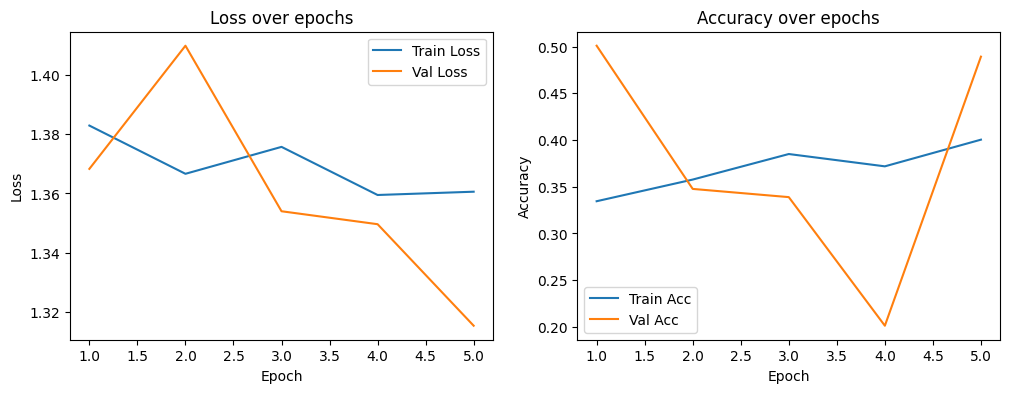

In [ ]:
# plotting learning curves

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over epochs')

plt.subplot(1,2,2)
plt.plot(range(1, num_epochs+1), train_accs, label='Train Acc')
plt.plot(range(1, num_epochs+1), val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over epochs')
plt.show()

In [ ]:
# evaluatting on test set

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.4734


In [ ]:
def train_and_evaluate_tinycnn(learning_rate, batch_size, optimizer_name, num_epochs=5):
    # Create fresh data loaders with given batch size
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # New model
    model = TinyCNN(num_classes=4).to(device)
    criterion = nn.CrossEntropyLoss()

    # Choose optimizer
    if optimizer_name.lower() == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name.lower() == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    else:
        raise ValueError("Use 'adam' or 'sgd'")

    # Train
    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        # optional: print progress

    # Evaluate on test
    _, test_acc = evaluate(model, test_loader, criterion, device)
    return test_acc

In [ ]:
# hyperparameter combinations and run experiments
# List of configurations
configs = [
    {'name': 'Baseline (Adam, lr=0.001, batch=32)', 'opt': 'adam', 'lr': 0.001, 'batch': 32},
    {'name': 'Adam lr=0.0005, batch=64', 'opt': 'adam', 'lr': 0.0005, 'batch': 64},
    {'name': 'SGD lr=0.01, batch=32', 'opt': 'sgd', 'lr': 0.01, 'batch': 32},
    {'name': 'Adam lr=0.001, batch=16', 'opt': 'adam', 'lr': 0.001, 'batch': 16},
]

results = []

for cfg in configs:
    print(f"\n--- Running: {cfg['name']} ---")
    acc = train_and_evaluate_tinycnn(cfg['lr'], cfg['batch'], cfg['opt'], num_epochs=5)
    results.append({
        'Configuration': cfg['name'],
        'Optimizer': cfg['opt'],
        'Learning Rate': cfg['lr'],
        'Batch Size': cfg['batch'],
        'Test Accuracy': round(acc, 4)
    })

# Display results table
import pandas as pd
results_df = pd.DataFrame(results)
print("\n=== Hyperparameter Tuning Results ===")
print(results_df.to_string(index=False))


--- Running: Baseline (Adam, lr=0.001, batch=32) ---

--- Running: Adam lr=0.0005, batch=64 ---

--- Running: SGD lr=0.01, batch=32 ---

--- Running: Adam lr=0.001, batch=16 ---

=== Hyperparameter Tuning Results ===
                      Configuration Optimizer  Learning Rate  Batch Size  Test Accuracy
Baseline (Adam, lr=0.001, batch=32)      adam         0.0010          32         0.5703
           Adam lr=0.0005, batch=64      adam         0.0005          64         0.5563
              SGD lr=0.01, batch=32       sgd         0.0100          32         0.5531
            Adam lr=0.001, batch=16      adam         0.0010          16         0.6250


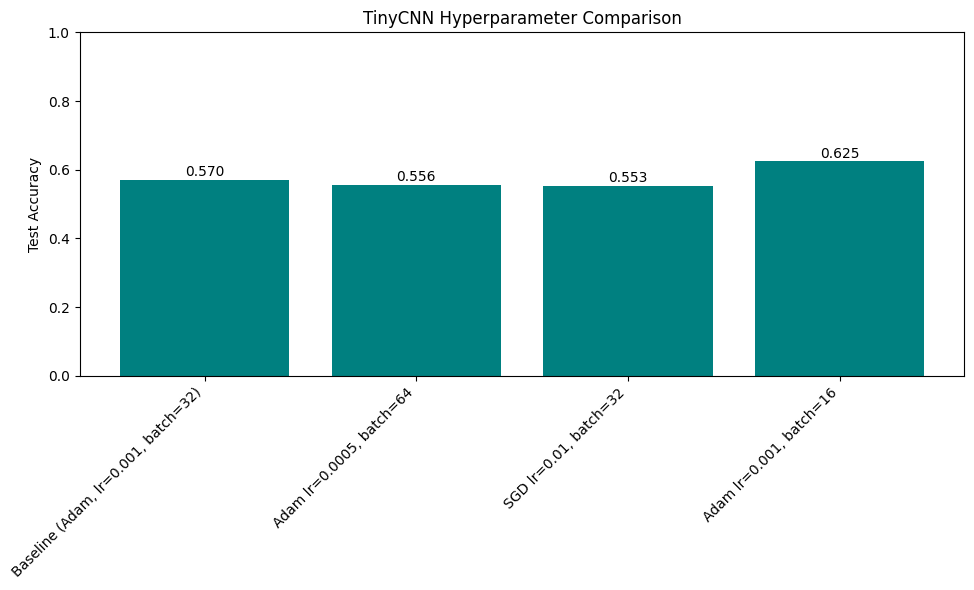


Best configuration: Adam lr=0.001, batch=16 with accuracy 0.6250


In [ ]:
# bar chart visualisations
plt.figure(figsize=(10,6))
plt.bar(results_df['Configuration'], results_df['Test Accuracy'], color='teal')
plt.ylim(0, 1)
plt.ylabel('Test Accuracy')
plt.title('TinyCNN Hyperparameter Comparison')
plt.xticks(rotation=45, ha='right')
for i, acc in enumerate(results_df['Test Accuracy']):
    plt.text(i, acc + 0.01, f'{acc:.3f}', ha='center')
plt.tight_layout()
plt.show()

best_config = results_df.loc[results_df['Test Accuracy'].idxmax()]
print(f"\nBest configuration: {best_config['Configuration']} with accuracy {best_config['Test Accuracy']:.4f}")

In [ ]:
# training the final best model with the best config

# best parameters
best_lr = 0.001
best_batch = 16
best_optimizer = 'adam'

# create fresh data loaders with best batch size
train_loader_best = DataLoader(train_dataset, batch_size=best_batch, shuffle=True, num_workers=2)
val_loader_best = DataLoader(val_dataset, batch_size=best_batch, shuffle=False, num_workers=2)
test_loader_best = DataLoader(test_dataset, batch_size=best_batch, shuffle=False, num_workers=2)

# new model
best_model = TinyCNN(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(best_model.parameters(), lr=best_lr)

num_epochs_final = 5
train_losses_final = []
val_losses_final = []
train_accs_final = []
val_accs_final = []

for epoch in range(num_epochs_final):
    train_loss, train_acc = train_one_epoch(best_model, train_loader_best, criterion, optimizer, device)
    val_loss, val_acc = evaluate(best_model, val_loader_best, criterion, device)
    train_losses_final.append(train_loss)
    val_losses_final.append(val_loss)
    train_accs_final.append(train_acc)
    val_accs_final.append(val_acc)
    print(f"Epoch {epoch+1}/{num_epochs_final}")
    print(f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}\n")

# Evaluate on test set
test_loss, test_acc = evaluate(best_model, test_loader_best, criterion, device)
print(f"Final Test Accuracy: {test_acc:.4f}")

Epoch 1/5
Train Loss: 1.0539 Acc: 0.4878
Val Loss: 0.9787 Acc: 0.5107

Epoch 2/5
Train Loss: 0.9533 Acc: 0.5342
Val Loss: 0.9213 Acc: 0.5459

Epoch 3/5
Train Loss: 0.9139 Acc: 0.5583
Val Loss: 0.9029 Acc: 0.5625

Epoch 4/5
Train Loss: 0.8786 Acc: 0.5674
Val Loss: 0.8398 Acc: 0.5850

Epoch 5/5
Train Loss: 0.8315 Acc: 0.5935
Val Loss: 0.7903 Acc: 0.6211

Final Test Accuracy: 0.6188


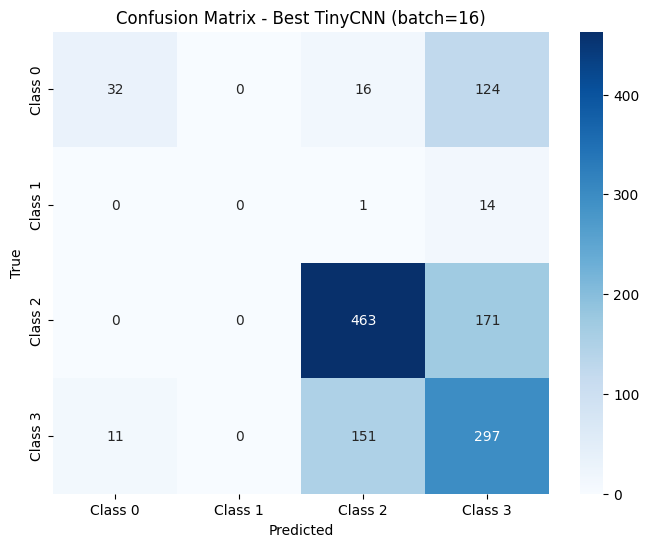

              precision    recall  f1-score   support

     Class 0       0.74      0.19      0.30       172
     Class 1       0.00      0.00      0.00        15
     Class 2       0.73      0.73      0.73       634
     Class 3       0.49      0.65      0.56       459

    accuracy                           0.62      1280
   macro avg       0.49      0.39      0.40      1280
weighted avg       0.64      0.62      0.60      1280



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels

y_pred, y_true = get_predictions(best_model, test_loader_best, device)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'],
            yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Best TinyCNN (batch=16)')
plt.show()

# Classification report (precision, recall, f1-score)
print(classification_report(y_true, y_pred, target_names=['Class 0', 'Class 1', 'Class 2', 'Class 3']))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


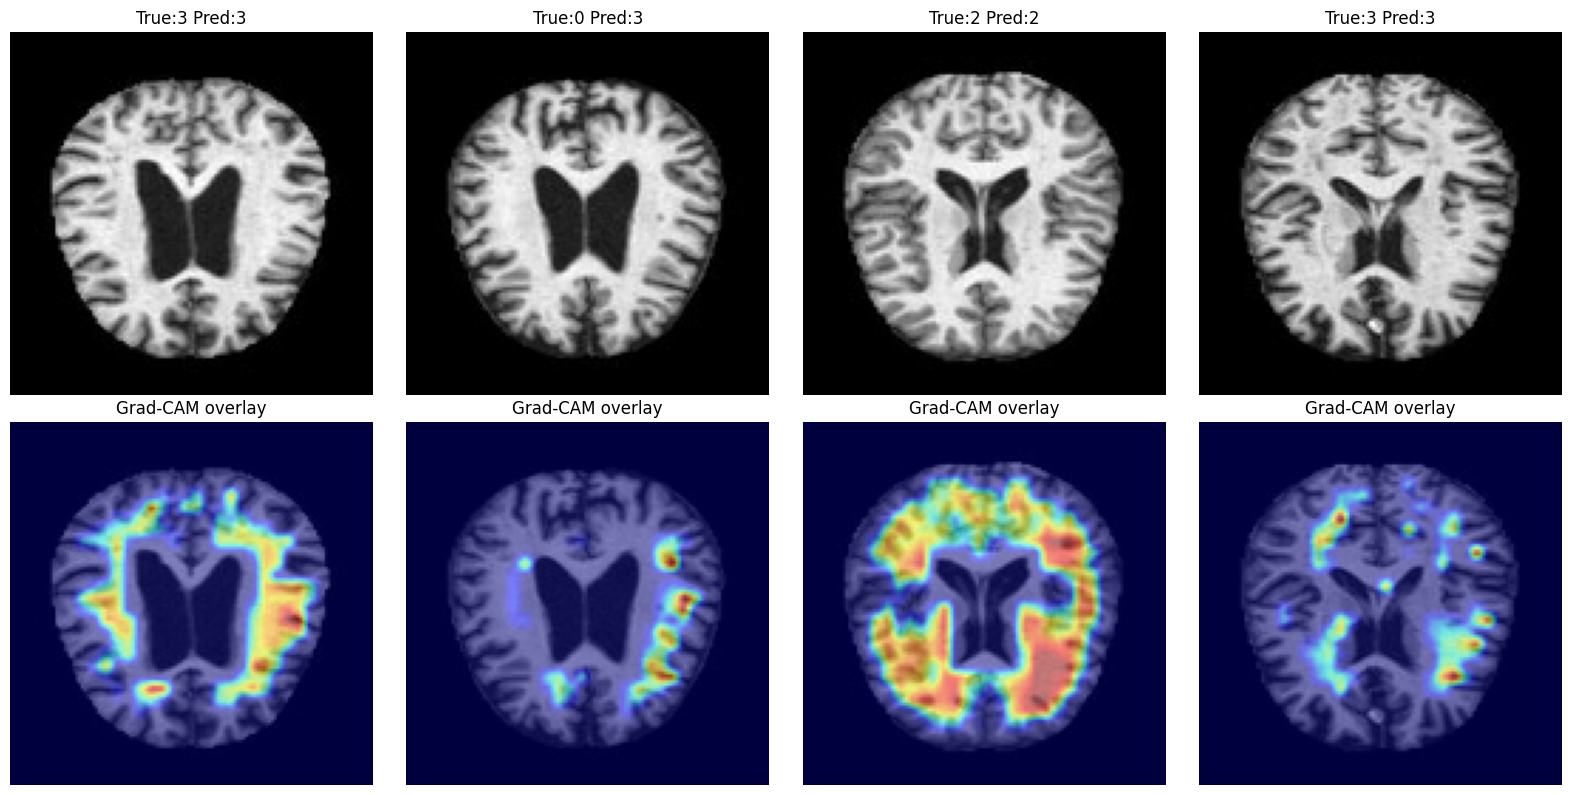

In [ ]:
# Grad-CAM Visualisation
import torch.nn.functional as F
from torch.nn import ReLU

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        self._register_hooks()

    def _register_hooks(self):
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]
        def forward_hook(module, input, output):
            self.activations = output
        self.hook_handles.append(self.target_layer.register_backward_hook(backward_hook))
        self.hook_handles.append(self.target_layer.register_forward_hook(forward_hook))

    def remove_hooks(self):
        for handle in self.hook_handles:
            handle.remove()

    def generate(self, input_image, target_class=None):
        self.model.eval()
        output = self.model(input_image.unsqueeze(0))  # add batch dim
        if target_class is None:
            target_class = output.argmax().item()

        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1
        output.backward(gradient=one_hot)

        weights = self.gradients.mean(dim=[2,3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = ReLU()(cam)
        cam = F.interpolate(cam, size=(128,128), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().detach().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, target_class

# Choose the last convolutional layer (index -3 in features: Conv2d before final MaxPool)
target_layer = best_model.features[-3]  # the Conv2d(32,64)
grad_cam = GradCAM(best_model, target_layer)

# Pick a few test images (correct and incorrect predictions)
test_iter = iter(test_loader_best)
images, labels = next(test_iter)

# We'll show first 4 images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for idx in range(4):
    img = images[idx].to(device)           # shape [1, 128, 128]
    true_lbl = labels[idx].item()

    with torch.no_grad():
        out = best_model(img.unsqueeze(0))   # model expects batch dim, so keep this
        pred_lbl = out.argmax().item()

    # Generate heatmap – pass img (3D) not img.unsqueeze(0)
    heatmap, _ = grad_cam.generate(img)

    # Plot original
    axes[0, idx].imshow(img.cpu().squeeze(), cmap='gray')
    axes[0, idx].set_title(f'True:{true_lbl} Pred:{pred_lbl}')
    axes[0, idx].axis('off')

    # Plot overlay
    axes[1, idx].imshow(img.cpu().squeeze(), cmap='gray')
    axes[1, idx].imshow(heatmap, cmap='jet', alpha=0.5)
    axes[1, idx].set_title('Grad-CAM overlay')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()
grad_cam.remove_hooks()

In [ ]:
torch.save(best_model.state_dict(), 'best_tinycnn_batch16.pth')

In [ ]:
# ----- RESNET18 MODEL ---- #

In [ ]:
# ResNet18 model
# ResNet18 model expects 224x224 rgb images normalised with imageNet mean/std, so we need to
# reuse our existing DataFrames but apply different transforms

from torchvision import transforms

#ResNet18 expects 3 channels, size 224x224, and specific normalisation
resnet_transform = transforms.Compose([
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)), # convert 1 channel to 3 channel by repeating
    transforms.Resize((224, 224)), # ResNet input size
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

class MRIResNetDataset(Dataset):
  def __init__(self, dataframe, transform=None):
    self.dataframe = dataframe.reset_index(drop=True)
    self.transform = transform

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    img = self.dataframe.iloc[idx]['image'].astype(np.float32) # (128,128)
    label = self.dataframe.iloc[idx]['label']
    # convert to tensor, add channel -> (1,128,128), then [0,1]
    img = torch.from_numpy(img).unsqueeze(0) / 255.0
    if self.transform:
      img = self.transform(img)
    return img, label

batch_size_resnet = 16

train_dataset_resnet = MRIResNetDataset(train_sub_df, transform=resnet_transform)
val_dataset_resnet = MRIResNetDataset(val_df, transform=resnet_transform)
test_dataset_resnet = MRIResNetDataset(test_df, transform=resnet_transform)

train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=batch_size_resnet, shuffle=True, num_workers=2)
val_loader_resnet = DataLoader(val_dataset_resnet, batch_size=batch_size_resnet, shuffle=False, num_workers=2)
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=batch_size_resnet, shuffle=False, num_workers=2)

# Quick check
images, labels = next(iter(train_loader_resnet))
print(f"ResNet input shape: {images.shape}")  # should be [16, 3, 224, 224]

ResNet input shape: torch.Size([16, 3, 224, 224])


In [ ]:
# load pretrained resnet18 and modify it
import torchvision.models as models

# load pretrained resnet18
resnet = models.resnet18(pretrained=True)

# freeze all layers (so we only train the new head)
for param in resnet.parameters():
  param.requires_grad = False

# replace the final fully connected layer to output 4 classes
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 4)

# Move to GPU
resnet = resnet.to(device)

# Optional: unfreeze the last few layers for fine-tuning (we'll start with only head)
# For now, only the new fc layer will be trained

print(resnet)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 138MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# training only the new head of the resnet18

criterion_resnet = nn.CrossEntropyLoss()
# Only parameters with requires_grad=True (i.e., the new fc layer) will be updated
optimizer_resnet = optim.Adam(resnet.fc.parameters(), lr=0.001)

num_epochs_resnet = 5

train_losses_resnet, val_losses_resnet = [], []
train_accs_resnet, val_accs_resnet = [], []

# run the 5 epochs
for epoch in range(num_epochs_resnet):
    train_loss, train_acc = train_one_epoch(resnet, train_loader_resnet, criterion_resnet, optimizer_resnet, device)
    val_loss, val_acc = evaluate(resnet, val_loader_resnet, criterion_resnet, device)
    train_losses_resnet.append(train_loss)
    val_losses_resnet.append(val_loss)
    train_accs_resnet.append(train_acc)
    val_accs_resnet.append(val_acc)
    print(f"Epoch {epoch+1}/{num_epochs_resnet}")
    print(f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}\n")

Epoch 1/5
Train Loss: 0.9644 Acc: 0.5493
Val Loss: 0.9002 Acc: 0.5723

Epoch 2/5
Train Loss: 0.8829 Acc: 0.5933
Val Loss: 0.9549 Acc: 0.5527

Epoch 3/5
Train Loss: 0.8663 Acc: 0.5977
Val Loss: 0.8718 Acc: 0.5947

Epoch 4/5
Train Loss: 0.8619 Acc: 0.5950
Val Loss: 0.8355 Acc: 0.6104

Epoch 5/5
Train Loss: 0.7919 Acc: 0.6343
Val Loss: 0.8275 Acc: 0.6133



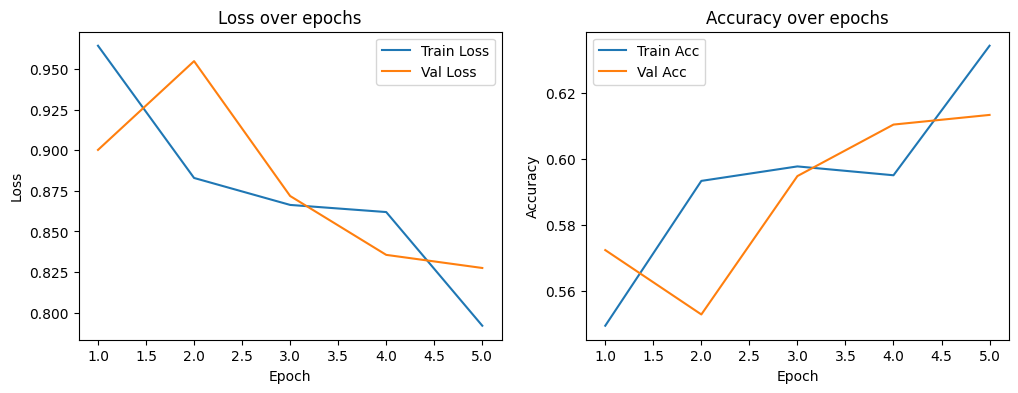

In [ ]:
# plotting learning curves

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1, num_epochs_resnet+1), train_losses_resnet, label='Train Loss')
plt.plot(range(1, num_epochs_resnet+1), val_losses_resnet, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over epochs')

plt.subplot(1,2,2)
plt.plot(range(1, num_epochs_resnet+1), train_accs_resnet, label='Train Acc')
plt.plot(range(1, num_epochs_resnet+1), val_accs_resnet, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over epochs')
plt.show()

In [ ]:
# similar to cell 8, plot the results of resent on test set
test_loss_resnet, test_acc_resnet = evaluate(resnet, test_loader_resnet, criterion_resnet, device)
print(f"ResNet18 Test Accuracy: {test_acc_resnet:.4f}")
print(f"Baseline TinyCNN Test Accuracy: 0.6859")

ResNet18 Test Accuracy: 0.6078
Baseline TinyCNN Test Accuracy: 0.6859


In [ ]:
# clearly our tiny cnn model is actually better than the pretrained resnet18